<div style="
    background: linear-gradient(135deg, #5f0a87, #a4508b);
    color: #ffffff;
    font-weight: bold;
    padding: 30px;
    border-radius: 20px;
    text-align: center;
    font-size: 36px;
    box-shadow: 0 10px 30px rgba(0,0,0,0.5);
    font-family: 'Segoe UI', sans-serif;
    letter-spacing: 2px;
">
    <span style="color:#ffffff; text-shadow:0 0 10px #ffffff;">
     Automated Image Recognition using Deep Learning (REAL OR FAKE)
    </span>
    <br>
    <span style="color:#ffd700; text-shadow:0 0 10px #ffd700;">
        DETECTION
    </span>
</div>

<div style="background-color: #001f3f;
            color: #00eaff;
            font-weight: bold;
            padding: 13px;
            border-radius: 30px;
            text-align: center;
            font-size: 28px;
            border: 4px groove #00eaff;">
IMPORT LIBRARIES, LAYERS, OPTIMIZERS
</div>

In [22]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('dark_background')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder 
from tensorflow.keras.utils import to_categorical
import os
from tensorflow.keras.optimizers import Adam
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [23]:
encoder=OneHotEncoder()
encoder.fit([[0],[1]])

OneHotEncoder()

In [24]:
data=[]
paths=[]
result=[]
for r,d,f in os.walk(r"C:\Users\tsiha\Desktop\real_and_fake_face\training_fake"):
    for file in f:
        if'.jpg' or '.jpeg' in file:
            paths.append(os.path.join(r,file))

for path in paths:
    img=Image.open(path)
    img=img.resize((128,128))
    img=np.array(img)
    if(img.shape==(128,128,3)):
        data.append(np.array(img))
        result.append(encoder.transform([[1]]).toarray())

In [25]:
paths=[]
for r,d,f in os.walk(r"C:\Users\tsiha\Desktop\real_and_fake_face\training_real"):
    for file in f:
        if'.jpg' or '.jpeg' in file:
            paths.append(os.path.join(r,file))

for path in paths:
    img=Image.open(path)
    img=img.resize((128,128))
    img=np.array(img)
    if(img.shape==(128,128,3)):
        data.append(np.array(img))
        result.append(encoder.transform([[0]]).toarray())

In [26]:
data=np.array(data)
data.shape

(2041, 128, 128, 3)

In [27]:
result=np.array(result)
result=result.reshape(2041,2)

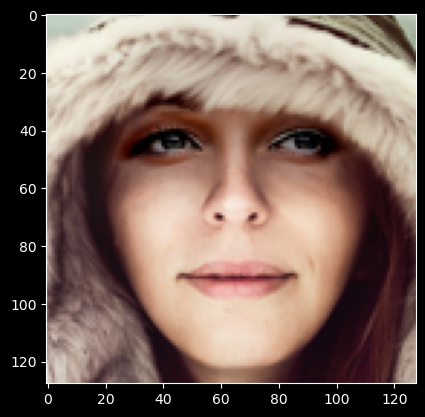

In [28]:
plt.imshow(data[78])

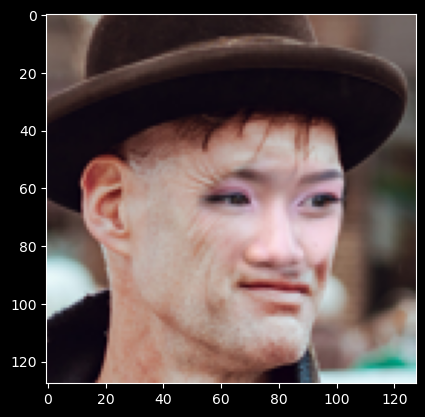

In [29]:
plt.imshow(data[102])

<div style="background-color: #001f3f;
            color: #00eaff;
            font-weight: bold;
            padding: 13px;
            border-radius: 30px;
            text-align: center;
            font-size: 28px;
            border: 4px groove #00eaff;">
SPLITTING AND SHUFFLING DATA
</div>

In [30]:
x_train,x_test,y_train,y_test=train_test_split(data,result,test_size=0.2,shuffle=True,random_state=0)

In [55]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

dataset_path = r"C:\Users\tsiha\Desktop\real_and_fake_face_detection\real_and_fake_face"

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

train_data = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

val_data = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

Found 1633 images belonging to 2 classes.
Found 408 images belonging to 2 classes.


<div style="background-color: #001f3f;
            color: #00eaff;
            font-weight: bold;
            padding: 13px;
            border-radius: 30px;
            text-align: center;
            font-size: 28px;
            border: 4px groove #00eaff;">
ADDING LAYERS
</div>

In [56]:
model = Sequential()

model.add(Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64,(3,3),activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128,(3,3),activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(256,activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(1,activation='sigmoid'))

In [57]:
print(model.summary())

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)                    │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 222, 222, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_9 (MaxPooling2D)       │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_10 (Conv2D)                   │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 109, 109, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_10 (MaxPooling2D)      │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_11 (Conv2D)                   │ (None, 52, 52, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 52, 52, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_11 (MaxPooling2D)      │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_3 (Flatten)                  │ (None, 86528)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 256)                 │      22,151,424 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 1)                   │             257 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 22,245,825 (84.86 MB)

 Trainable params: 22,245,377 (84.86 MB)

 Non-trainable params: 448 (1.75 KB)

None


<div style="background-color: #001f3f;
            color: #00eaff;
            font-weight: bold;
            padding: 13px;
            border-radius: 30px;
            text-align: center;
            font-size: 28px;
            border: 4px groove #00eaff;">
COMPLIE
</div>

In [58]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [59]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20
)

Epoch 1/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 187s 3s/step - accuracy: 0.5144 - loss: 6.4358 - val_accuracy: 0.4828 - val_loss: 5.2260
Epoch 2/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 173s 3s/step - accuracy: 0.5493 - loss: 1.0094 - val_accuracy: 0.5466 - val_loss: 2.8077
Epoch 3/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 172s 3s/step - accuracy: 0.5591 - loss: 0.7298 - val_accuracy: 0.5294 - val_loss: 10.4268
Epoch 4/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 171s 3s/step - accuracy: 0.5591 - loss: 0.7392 - val_accuracy: 0.5368 - val_loss: 3.8820
Epoch 5/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 184s 4s/step - accuracy: 0.5646 - loss: 0.7127 - val_accuracy: 0.5392 - val_loss: 1.4352
Epoch 6/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 189s 4s/step - accuracy: 0.5664 - loss: 0.6787 - val_accuracy: 0.5417 - val_loss: 1.1070
Epoch 7/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 186s 4s/step - accuracy: 0.5891 - loss: 0.7174 - val_accuracy: 0.5319 - val_loss: 0.7474
Epoch 8/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 185s 4s/step - accuracy: 0.5867 - loss: 0.6984 - val_accuracy: 0.5221 - 

<div style="background-color: #001f3f;
            color: #00eaff;
            font-weight: bold;
            padding: 13px;
            border-radius: 30px;
            text-align: center;
            font-size: 28px;
            border: 4px groove #00eaff;">
EVALUATE
</div>

In [60]:
loss, accuracy = model.evaluate(val_data)

print(f"Accuracy: {accuracy*100:.2f}%")

13/13 ━━━━━━━━━━━━━━━━━━━━ 28s 2s/step - accuracy: 0.5343 - loss: 0.6827
Accuracy: 53.43%


<div style="background-color: #001f3f;
            color: #00eaff;
            font-weight: bold;
            padding: 13px;
            border-radius: 30px;
            text-align: center;
            font-size: 28px;
            border: 4px groove #00eaff;">
PREDICTION
</div>

In [61]:
import numpy as np
from tensorflow.keras.preprocessing import image

img = image.load_img(r"C:\Users\tsiha\Desktop\real_and_fake_face\training_fake\easy_1_1110.jpg", target_size=(224,224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array,axis=0)
img_array = img_array/255

prediction = model.predict(img_array)

if prediction[0][0] > 0.5:
    print("Real Face")
else:
    print("Fake Face")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 563ms/step
Real Face
